In [1]:
import os

import torch
import torch.nn as nn
import torch.utils.data as data_utils

import random
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from dataclasses import dataclass, field

# Wine Quality Regression with Regularization

Building on the basics introduced in *PyTorch 101*, this notebook applies a Neural Network to a real-world regression task: predicting wine quality from physicochemical measurements.

The following exercise includes:

- Exploring the *WineQT* dataset.
- Preprocessing features and target with min-max normalization using a three-way split (train / validation / test).
- Building a deep MLP regression model.
- Comparing three training strategies: **Baseline** (no regularization), **Early Stopping**, and **Dropout**.
- Evaluating each experiment with denormalized MSE, RMSE, and MAPE on the original quality scale.

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED);

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yasserh/wine-quality-dataset")

print("Path to dataset files:", path)

import shutil
shutil.move(path, './data/winequality')

## Dataset

The *WineQT* dataset contains physicochemical measurements of red wine samples along with a quality score assigned by human tasters.

**Features (11 inputs):**
- `fixed acidity`, `volatile acidity`, `citric acid` — acidity components
- `residual sugar` — sugar remaining after fermentation
- `chlorides` — salt content
- `free sulfur dioxide`, `total sulfur dioxide` — preservative levels
- `density`, `pH`, `sulphates`, `alcohol` — chemical properties

**Target:**
- `quality`: integer score from **3 to 8** (higher is better)

In [55]:
df = pd.read_csv('data/winequality/WineQT.csv')
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


### Exploratory Data Analysis

Let's explore the dataset to understand feature distributions, value ranges, and check for missing values before preprocessing.

In [56]:
# check for null values
np.count_nonzero(df.isnull().values)

0

In [57]:
# drop id column
df = df.drop(columns='Id', axis=1)
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [58]:
# check data magnitude (definitely needs scaling/normalization)
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


### Data Splitting

We first carve out a **test set** (10%) using stratified sampling on `quality` to preserve the score distribution. The remaining 90% becomes the training+validation pool, which is split again later to create an equal-sized validation set.

In [59]:
X = df[df.columns[:-1]]
y = pd.DataFrame(df['quality'].values, columns=['quality'])

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, 
    test_size=.10, random_state=SEED,
    stratify=y
)

In [60]:
print(X_train_val.shape, y_train_val.shape)
print(X_test.shape, y_test.shape)

(1028, 11) (1028, 1)
(115, 11) (115, 1)


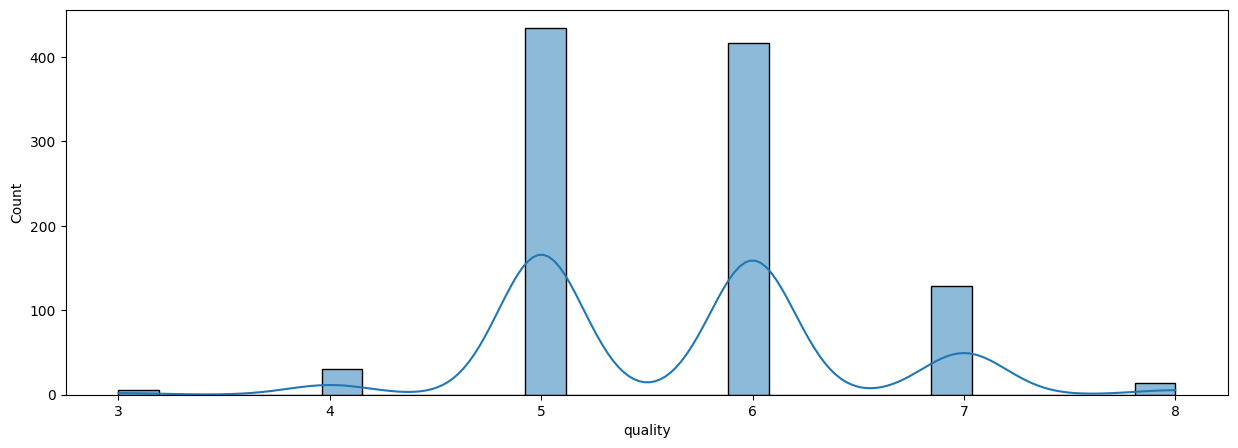

In [61]:
plt.figure(figsize=(15, 5))
sns.histplot(data=y_train_val, x='quality', kde=True)
plt.show();

## Data Preprocessing

### Feature Normalization

The `describe()` output shows features span very different scales — `total sulfur dioxide` reaches 289 while `density` hovers near 1. This imbalance can destabilize gradient updates.

We apply **min-max normalization** to both features `X` and the target `y`, scaling all values to `[0, 1]`. Statistics are computed **only on the training+validation set** and reused for the test set to prevent **data leakage**.

> **Note:** Because `quality` is also normalized, all MSE values reported during training are in the `[0, 1]` space and will appear small. The final evaluation section converts predictions back to the original 3–8 scale.

In [62]:
# normalization
max_df = X_train_val.max()
min_df = X_train_val.min()

max_t = y_train_val.max()
min_t = y_train_val.min()

X_train_val_norm = (X_train_val-min_df)/(max_df-min_df)
X_test = (X_test-min_df)/(max_df-min_df)

y_train_val_norm = (y_train_val-min_t)/(max_t-min_t)
y_test = (y_test-min_t)/(max_t-min_t)


print(f"Input shape: {X_train_val_norm.shape}")
print(f"Label shape: {y_train_val.shape}")

Input shape: (1028, 11)
Label shape: (1028, 1)


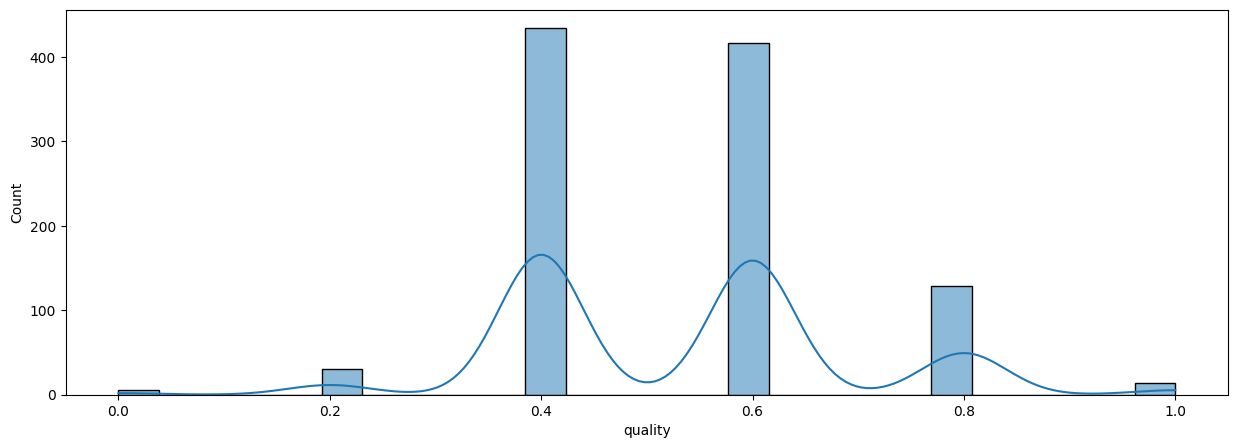

In [63]:
plt.figure(figsize=(15, 5))
sns.histplot(data=y_train_val_norm, x='quality', kde=True)
plt.show();

### Validation Split

We split the training+validation pool into a **train** set and a **validation** set of equal size to the test set. Using `stratify=y_train_val` preserves the quality score distribution across both splits.

In [64]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val_norm, y_train_val_norm,
    test_size=len(X_test), random_state=SEED,
    stratify=y_train_val
)

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)

(913, 11) (913, 1)
(115, 11) (115, 1)


In [65]:
X_train = X_train.reset_index().drop(columns=['index'])
X_test = X_test.reset_index().drop(columns=['index'])
X_val = X_val.reset_index().drop(columns=['index'])

y_train = y_train.reset_index().drop(columns=['index'])
y_test = y_test.reset_index().drop(columns=['index'])
y_val = y_val.reset_index().drop(columns=['index'])

### Dataset Creation

We convert the preprocessed DataFrames into `TensorDataset` objects and wrap them in `DataLoader`s. The training loader uses `shuffle=True` to randomize mini-batch order each epoch; validation and test loaders use `shuffle=False` to keep evaluation deterministic.

In [66]:
batch_size = 32

train_dataset = data_utils.TensorDataset(torch.tensor(X_train.values, dtype=torch.float32), 
                                   torch.tensor(y_train.values, dtype=torch.float32))
train_loader = data_utils.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)


test_dataset = data_utils.TensorDataset(torch.tensor(X_test.values, dtype=torch.float32), 
                                   torch.tensor(y_test.values, dtype=torch.float32))
test_loader = data_utils.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


val_dataset = data_utils.TensorDataset(torch.tensor(X_val.values, dtype=torch.float32), 
                                   torch.tensor(y_val.values, dtype=torch.float32))
val_loader = data_utils.DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

## Training Infrastructure

To cleanly compare multiple training strategies without repeating code, we define reusable components before running any experiments: an `Experiment` dataclass, an `EarlyStopping` callback, a training loop, and a plotting utility.

In [67]:
@dataclass
class Experiment:
    "Represents a model and all its hyperparameters for a given experiment"

    name: str
    checkpoints_folder: str
    checkpoint_name: str
    model: object
    use_early_stopping: bool
    loss_fn: object
    optimizer: object
    color: str
    alpha: float
    checkpoint_save_path: str = None
    val_mse: float = None
    lr: float = 1e-5
    epochs: int = 600
    patience: int = 10
    min_delta: float = 0
    epochs_count: list = field(default_factory = list)
    train_loss_values: list = field(default_factory = list)
    val_loss_values: list = field(default_factory = list)
    plt_arg_training: list = field(default_factory = list)
    plt_args_validation: list = field(default_factory = list)
    
    def __post_init__(self):
        self.optimizer = self.optimizer(
            params= self.model.parameters(), 
            lr = self.lr
        )

        self.checkpoints_folder = os.path.join(self.checkpoints_folder, self.name)
        os.makedirs(self.checkpoints_folder, exist_ok=True)
        self.checkpoint_save_path = os.path.join(self.checkpoints_folder, self.checkpoint_name)

### Early Stopping

`EarlyStopping` monitors validation loss after each epoch. If the loss does not improve by more than `min_delta` for `patience` consecutive epochs, training halts. The best model weights are saved to disk and restored at the end, so the final model reflects the best generalization — not the last (potentially overfit) state.

In [68]:
class EarlyStopping:
    def __init__(self, save_path, patience=5, min_delta=0):
        super().__init__()

        self.save_path = save_path
        self.patience = patience
        self.min_delta = min_delta
        self.min_val_loss = None
        self.counter = 0
        self.early_stop = False

    def __call__(self, validation_loss, model):

        if self.min_val_loss is None:  # first epoch
            self.min_val_loss = validation_loss
            self.save_checkpoint(model)
        
        elif (self.min_val_loss - validation_loss) > self.min_delta:   # the model is getting better
            self.min_val_loss = validation_loss
            self.save_checkpoint(model)
            self.counter = 0
        
        else: # the model is not getting better
            self.counter += 1

            if self.counter >= self.patience:
                self.early_stop = True

    def save_checkpoint(self, model):
        torch.save(model.state_dict(), self.save_path)


### Training Loop

`train_experiment` encapsulates the standard PyTorch train/eval loop for an `Experiment` object. It tracks loss history for later visualization and, when `use_early_stopping=True`, calls the `EarlyStopping` callback after each validation pass.

In [69]:
def train_experiment(exp: Experiment, train_loader, val_loader):
    exp.epochs_count = []
    exp.train_loss_values = []
    exp.val_loss_values = []

    if exp.use_early_stopping:
        early_stopping = EarlyStopping(
            exp.checkpoint_save_path, 
            exp.patience,
            min_delta = exp.min_delta
        )
    
    for epoch in range(exp.epochs):
        exp.model.train()

        train_loss_epoch = 0
        for i, data in enumerate(train_loader, 0):
            X = data[0]
            y = data[1]

            exp.optimizer.zero_grad()
            y_pred = exp.model(X)
            train_loss = exp.loss_fn(y_pred, y)
            train_loss_epoch += train_loss
            train_loss.backward()
            exp.optimizer.step()
        
        exp.model.eval()
        val_loss_epoch = 0
        for j, data in enumerate(val_loader, 0):
            X = data[0]
            y = data[1]
            with torch.no_grad():
                y_pred = exp.model(X)
                val_loss = exp.loss_fn(y_pred, y)
            val_loss_epoch += val_loss
            
        exp.epochs_count.append(epoch)
        exp.train_loss_values.append(train_loss_epoch.detach().numpy()/len(train_loader))
        exp.val_loss_values.append(val_loss_epoch.detach().numpy()/len(val_loader))
        print(f"Epoch: {epoch:<4}  |  Train Loss: {train_loss_epoch/len(train_loader):.6f}  |  Val Loss: {val_loss_epoch/len(val_loader):.6f}")

        if exp.use_early_stopping:
            early_stopping(val_loss_epoch/len(val_loader), exp.model)
            if early_stopping.early_stop:
                print(f"Early stopping at epoch: {epoch}")
                break

    if exp.use_early_stopping:
        exp.model.load_state_dict(torch.load(exp.checkpoint_save_path))

In [70]:
def test_experiment(exp: Experiment, test_loader):
    tot_loss = 0
    exp.model.eval()
    for j, data in enumerate(test_loader, 0):

        X = data[0]
        y = data[1]

        with torch.no_grad():
            y_pred = exp.model(X)
            loss = exp.loss_fn(y_pred, y)

        tot_loss += loss
    
    return tot_loss.detach().numpy()/len(test_loader)

### Visualization

`plot_loss` renders two side-by-side panels: the full learning curve on a log scale (to see early dynamics) and a post-warmup linear view (to highlight the overfit gap). When early stopping is used, the faded tail shows the epochs discarded in favor of the best checkpoint.

In [71]:
def plot_loss(exp: Experiment, warmup=5):
    ec = exp.epochs_count
    tl = exp.train_loss_values
    vl = exp.val_loss_values

    TRAIN_COLOR = '#ff7f0e'
    VAL_COLOR = '#4D61E2'

    best_idx = len(ec) - exp.patience - 1 if exp.use_early_stopping else None

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    for ax, slice_start in [(axes[0], 0), (axes[1], warmup)]:
        ec_s = ec[slice_start:]
        tl_s = tl[slice_start:]
        vl_s = vl[slice_start:]

        if best_idx is not None:
            local_best = max(0, best_idx - slice_start)

            ax.plot(ec_s[:local_best + 1], tl_s[:local_best + 1], color=TRAIN_COLOR, alpha=1.0, label='Training')
            ax.plot(ec_s[:local_best + 1], vl_s[:local_best + 1], color=VAL_COLOR, alpha=1.0, label='Validation')

            if local_best < len(ec_s) - 1:
                ax.plot(ec_s[local_best:], tl_s[local_best:], color=TRAIN_COLOR, alpha=0.3)
                ax.plot(ec_s[local_best:], vl_s[local_best:], color=VAL_COLOR, alpha=0.3)
        else:
            ax.plot(ec_s, tl_s, color=TRAIN_COLOR, alpha=1.0, label='Training')
            ax.plot(ec_s, vl_s, color=VAL_COLOR, alpha=1.0, label='Validation')

        if slice_start > 0:
            ax.fill_between(ec_s, tl_s, vl_s, alpha=0.15, color='red', label='Overfit gap')

        ax.legend(loc='upper right')
        ax.grid(alpha=0.3)

    axes[0].set_yscale('log')
    axes[0].set_title(f'{exp.name} — MSE (log scale)')
    axes[1].set_title(f'{exp.name} — MSE (after warmup, epoch {warmup}+)')

    plt.tight_layout()
    plt.show()

## Experiments

We run three experiments on the same dataset split to compare different regularization strategies. All experiments use the `Adam` optimizer with `lr=1e-3` and `MSELoss`.

In [72]:
histories = []
names = []
colors = []
val_scores = []
test_scores = []

## Baseline

Base model with no ```Regularization```.

In [73]:

class BaselineModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features=11, out_features=256),
            nn.ReLU(),
            nn.Linear(in_features=256, out_features=128),
            nn.ReLU(),
            nn.Linear(in_features=128, out_features=64),
            nn.ReLU(),
            nn.Linear(in_features=64, out_features=1)
        )
    
    def forward(self, x):
        return self.net(x)


In [74]:
experiments = []

In [75]:
train_loss_values = []
val_loss_values = []
epochs_count = []

In [76]:
baseline = BaselineModel()
baseline_exp = Experiment(
    name='baseline',
    checkpoints_folder='models',
    checkpoint_name='model.pt',
    model = baseline,
    use_early_stopping=False,
    loss_fn=nn.MSELoss(),
    optimizer=torch.optim.Adam,
    lr=1e-3,
    epochs=1000,
    epochs_count=epochs_count,
    val_loss_values=val_loss_values,
    train_loss_values=train_loss_values,
    color="#FF7F0E",
    alpha=.3,
)

experiments.append(baseline_exp)

In [77]:
train_experiment(
    baseline_exp, 
    train_loader=train_loader, 
    val_loader=val_loader
)

Epoch: 0     |  Train Loss: 0.069787  |  Val Loss: 0.026627
Epoch: 1     |  Train Loss: 0.022344  |  Val Loss: 0.020441
Epoch: 2     |  Train Loss: 0.018714  |  Val Loss: 0.017365
Epoch: 3     |  Train Loss: 0.017361  |  Val Loss: 0.016924
Epoch: 4     |  Train Loss: 0.016463  |  Val Loss: 0.015708
Epoch: 5     |  Train Loss: 0.016487  |  Val Loss: 0.016142
Epoch: 6     |  Train Loss: 0.016322  |  Val Loss: 0.015323
Epoch: 7     |  Train Loss: 0.015855  |  Val Loss: 0.014810
Epoch: 8     |  Train Loss: 0.015772  |  Val Loss: 0.015380
Epoch: 9     |  Train Loss: 0.015538  |  Val Loss: 0.015864
Epoch: 10    |  Train Loss: 0.016548  |  Val Loss: 0.017446
Epoch: 11    |  Train Loss: 0.015713  |  Val Loss: 0.014716
Epoch: 12    |  Train Loss: 0.015527  |  Val Loss: 0.014850
Epoch: 13    |  Train Loss: 0.014986  |  Val Loss: 0.015905
Epoch: 14    |  Train Loss: 0.015158  |  Val Loss: 0.014508
Epoch: 15    |  Train Loss: 0.015037  |  Val Loss: 0.014675
Epoch: 16    |  Train Loss: 0.014902  | 

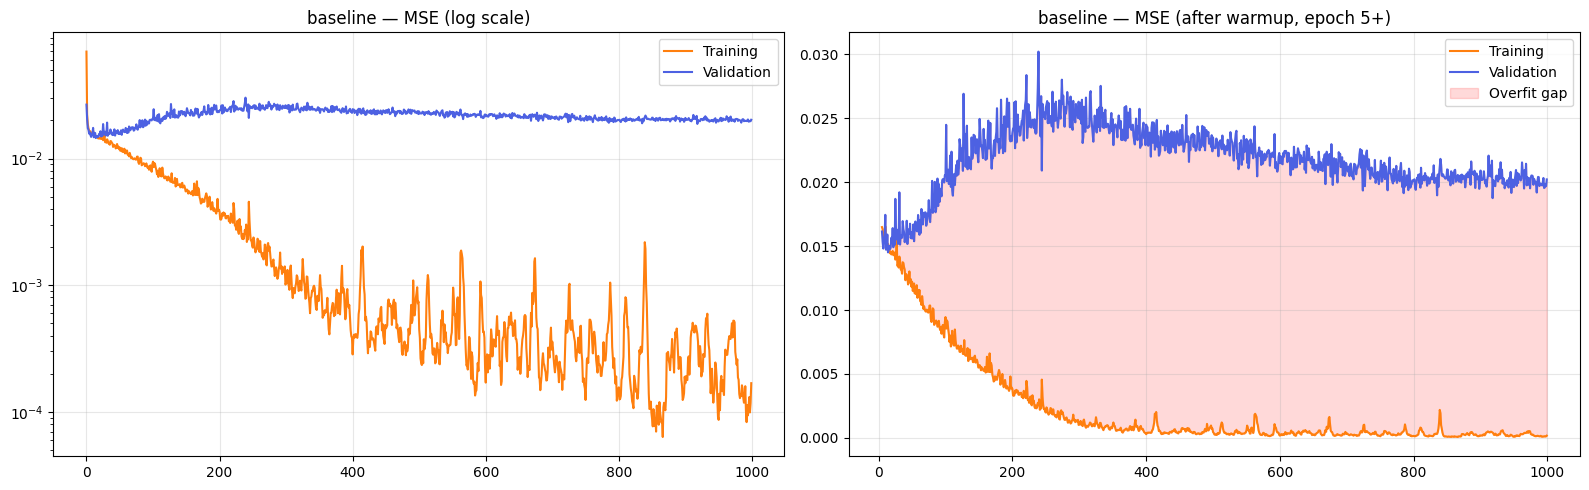

In [78]:
plot_loss(baseline_exp)

In [79]:
baseline_save_folder = 'models/baseline'
os.makedirs(baseline_save_folder, exist_ok=True)
baseline_save_file = os.path.join(baseline_save_folder, 'model.pt')
torch.save(baseline.state_dict(), baseline_save_file)

## Early Stopping

The baseline model, as clearly shown in the plot, has a clear problem of ```Overfitting```.

Let's improve the baseline model using an early stopper in order to find an optimal number of epochs. To do that we need to save a checkpoint of the model each time it gets better after an epoch of training and not save it when it gets worse than the previous epoch so that we can ripristine the best model after the training.

In [80]:
train_loss_values_early_stopping = []
val_loss_values_early_stopping = []
epochs_count_early_stopping = []

In [81]:
early_stopping_exp = Experiment(
    name='early_stopping',
    checkpoints_folder='models',
    checkpoint_name='model.pt',
    model = BaselineModel(),
    use_early_stopping=True,
    loss_fn=nn.MSELoss(),
    optimizer=torch.optim.Adam,
    lr=1e-3,
    epochs=1000,
    patience=50,
    epochs_count=epochs_count_early_stopping,
    train_loss_values=train_loss_values_early_stopping,
    val_loss_values=val_loss_values_early_stopping,
    color='#4D61E2',
    alpha=.8
)

experiments.append(early_stopping_exp)

In [82]:
train_experiment(
    early_stopping_exp,
    train_loader=train_loader,
    val_loader=val_loader
)

Epoch: 0     |  Train Loss: 0.075116  |  Val Loss: 0.031956
Epoch: 1     |  Train Loss: 0.024374  |  Val Loss: 0.021520
Epoch: 2     |  Train Loss: 0.019422  |  Val Loss: 0.018656
Epoch: 3     |  Train Loss: 0.017803  |  Val Loss: 0.017268
Epoch: 4     |  Train Loss: 0.016979  |  Val Loss: 0.016400
Epoch: 5     |  Train Loss: 0.016625  |  Val Loss: 0.015672
Epoch: 6     |  Train Loss: 0.016337  |  Val Loss: 0.016181
Epoch: 7     |  Train Loss: 0.016138  |  Val Loss: 0.015593
Epoch: 8     |  Train Loss: 0.016549  |  Val Loss: 0.016146
Epoch: 9     |  Train Loss: 0.015896  |  Val Loss: 0.016088
Epoch: 10    |  Train Loss: 0.016305  |  Val Loss: 0.014552
Epoch: 11    |  Train Loss: 0.015386  |  Val Loss: 0.015138
Epoch: 12    |  Train Loss: 0.015758  |  Val Loss: 0.014972
Epoch: 13    |  Train Loss: 0.015420  |  Val Loss: 0.014796
Epoch: 14    |  Train Loss: 0.015377  |  Val Loss: 0.021615
Epoch: 15    |  Train Loss: 0.016831  |  Val Loss: 0.016477
Epoch: 16    |  Train Loss: 0.016404  | 

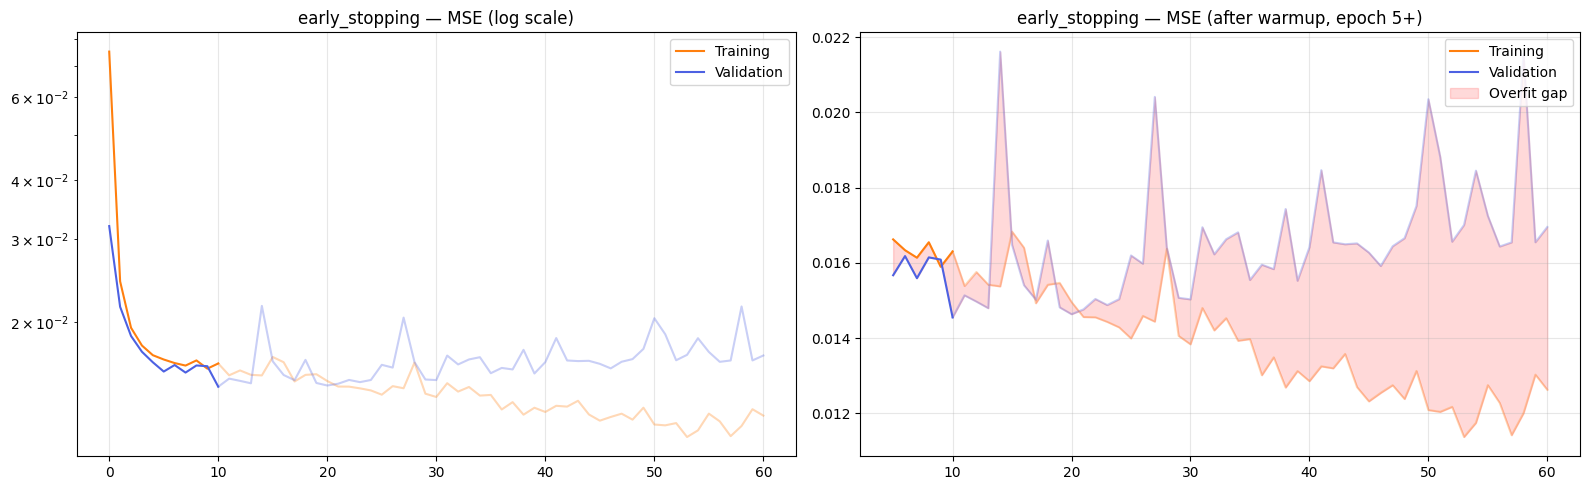

In [83]:
plot_loss(early_stopping_exp)

## Dropout

Another approach to combat overfitting is **Dropout**: during training, a fraction `p` of neuron activations are randomly zeroed out each forward pass. This prevents neurons from co-adapting and forces the network to learn more robust, distributed representations.

Here we add `Dropout(p=0.2)` after each hidden `ReLU` layer. Dropout is automatically disabled when the model is set to `.eval()` mode for validation and evaluation.

In [84]:
class DropoutModel(nn.Module):

    def __init__(self):

        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(in_features=11, out_features=256),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(in_features=256, out_features=128),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(in_features=128, out_features=64),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(in_features=64, out_features=1)
        )

    def forward(self, x):
        return self.net(x)

In [85]:
train_loss_values_dropout = []
val_loss_values_dropout = []
epochs_count_dropout = []

In [86]:
dropout_exp = Experiment(
    name='dropout',
    checkpoints_folder='models',
    checkpoint_name='model.pt',
    model = DropoutModel(),
    use_early_stopping=True,
    loss_fn=nn.MSELoss(),
    optimizer=torch.optim.Adam,
    lr=1e-3,
    epochs=1000,
    patience=50,
    epochs_count=epochs_count_dropout,
    train_loss_values=train_loss_values_dropout,
    val_loss_values=val_loss_values_dropout,
    alpha=.8,
    color='#B851D0'
)

In [87]:
train_experiment(dropout_exp, train_loader, val_loader)

Epoch: 0     |  Train Loss: 0.086145  |  Val Loss: 0.025689
Epoch: 1     |  Train Loss: 0.030257  |  Val Loss: 0.019863
Epoch: 2     |  Train Loss: 0.026895  |  Val Loss: 0.021819
Epoch: 3     |  Train Loss: 0.024793  |  Val Loss: 0.016647
Epoch: 4     |  Train Loss: 0.024999  |  Val Loss: 0.015877
Epoch: 5     |  Train Loss: 0.023422  |  Val Loss: 0.015162
Epoch: 6     |  Train Loss: 0.022393  |  Val Loss: 0.019182
Epoch: 7     |  Train Loss: 0.023223  |  Val Loss: 0.014971
Epoch: 8     |  Train Loss: 0.020687  |  Val Loss: 0.014984
Epoch: 9     |  Train Loss: 0.022187  |  Val Loss: 0.015226
Epoch: 10    |  Train Loss: 0.022127  |  Val Loss: 0.015094
Epoch: 11    |  Train Loss: 0.022080  |  Val Loss: 0.014882
Epoch: 12    |  Train Loss: 0.020079  |  Val Loss: 0.014595
Epoch: 13    |  Train Loss: 0.021497  |  Val Loss: 0.015276
Epoch: 14    |  Train Loss: 0.019547  |  Val Loss: 0.014321
Epoch: 15    |  Train Loss: 0.019947  |  Val Loss: 0.014667
Epoch: 16    |  Train Loss: 0.019753  | 

In [88]:
experiments.append(dropout_exp)

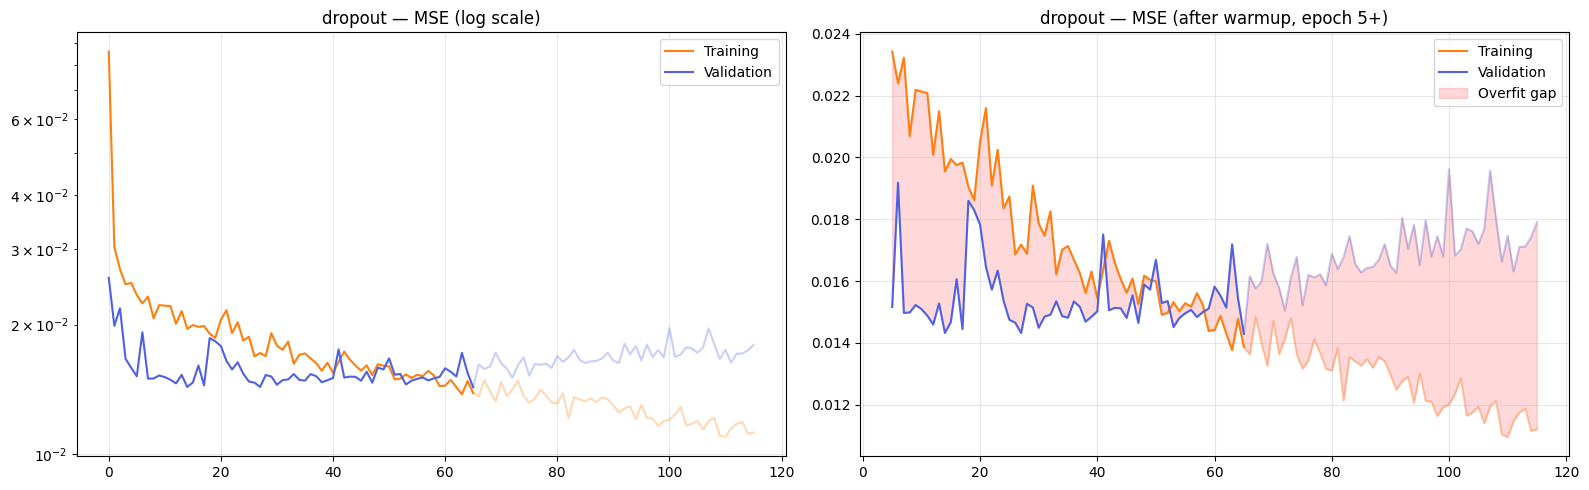

In [89]:
plot_loss(dropout_exp)

## Evaluation

With all three experiments trained, we compare their performance. We first use the `test_experiment` helper in normalized space to select the best experiment by validation MSE, then re-evaluate with denormalized metrics for interpretable results.

In [90]:
for exp in experiments:
    exp.val_mse = test_experiment(exp, val_loader)

list(map(lambda x: f"Exp {x.name}: MSE: {x.val_mse}", experiments))

['Exp baseline: MSE: 0.020217590034008026',
 'Exp early_stopping: MSE: 0.014551538042724133',
 'Exp dropout: MSE: 0.014296733774244785']

In [91]:
best_exp = list(sorted(experiments, key=lambda x: x.val_mse))[0]

### Denormalized Metrics

`evaluate_experiment` reverses the min-max normalization before computing errors, so all metrics are in the original quality scale (3–8):

- **MSE** — Mean Squared Error in original quality units
- **RMSE** — Root MSE: average error in quality points (e.g., RMSE = 0.6 means predictions are off by ~0.6 quality points on average)
- **MAPE** — Mean Absolute Percentage Error: how far off predictions are as a percentage of the true quality score

In [92]:
def evaluate_experiment(exp, loader, min_t, max_t):
    scale = float(max_t.values[0] - min_t.values[0])
    offset = float(min_t.values[0])

    exp.model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for X, y in loader:
            all_preds.append(exp.model(X))
            all_targets.append(y)

    preds   = torch.cat(all_preds).squeeze()   * scale + offset
    targets = torch.cat(all_targets).squeeze() * scale + offset

    mse  = float(((preds - targets) ** 2).mean())
    rmse = mse ** 0.5
    mape = float(((preds - targets).abs() / targets).mean() * 100)
    return mse, rmse, mape

In [93]:
print(f"{'Experiment':<20} {'Val MSE':>10} {'Val RMSE':>12} {'MAPE':>10}")
print("-" * 56)
mse, rmse, mape = evaluate_experiment(best_exp, val_loader, min_t, max_t)
best_exp.val_mse = mse
print(f"{best_exp.name:<20} {mse:>10.4f} {rmse:>12.4f} {mape:>9.2f}%")

Experiment              Val MSE     Val RMSE       MAPE
--------------------------------------------------------
dropout                  0.3644       0.6036      8.37%
